In [9]:
# 1. Import necessary libraries/packages
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [10]:
# 2. Standarize the column names
# 2.a Create a function to standarize the column names
def standardize_column_names(dataframe):
    """
    This function standardizes the name of columns in datasets.
    Convert names to lower case and separate words by lower script.
    Args:
        dataframe: is the set of data to obtain the name of columns and be able to standardize them.
    Return:
        the function prints the new name of columns after the standardized process.
    """
    import re
    # Select the culumns from dataframe
    column_names = dataframe.columns
    # Create an empty list to save the new names after the standarize process
    standard_column_names = []
    for item in column_names:
        item = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', item)
        standard_column_names.append(re.sub('([a-z0-9])([A-Z])', r'\1_\2', item).lower().replace(' ', ''))
    # Change the name of the dataframe's column to the new set
    dataframe.columns = standard_column_names
    # Print the new columns names
    print(dataframe.columns)

# Data Exploratory Analysis (EDA)

In [11]:
# 3. Load the dataset
data = pd.read_csv('C:/Users/paul_/OneDrive/Documentos/Python Scripts/mall_customers_unsupervised_learning/Mall_Customers.csv')

In [12]:
# 4. Explore the dataset
# 4.a Review the dataset info()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


This dataset contains 5 columns with 200 rows, each row contains basic information about a customer like their customerID, their age, gender their annual income and their spending score, this last one refers to a number between 1 and 100 assigned based on defined parameters like customer behavior and purchasing data.

In [13]:
# 4.b Verify for duplicates
print(f'Duplicates: {data.duplicated().sum()}')

Duplicates: 0


In [14]:
# 4.c Visualize the dataset content
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


The dataset contains no null values or duplicates so basically, the dataset information is complete and clean; however, next a standarization of the column names will be implemented for standarization and better readability.

In [15]:
# 5. Apply the function over the dataset to standarize the names
standardize_column_names(data)

Index(['customer_id', 'genre', 'age', 'annual_income(k$)',
       'spending_score(1-100)'],
      dtype='object')


In [16]:
# 6. Shape of the dataset
data.shape

(200, 5)

Dataset columns names have been standarized now, The shape of the dataset is 5 characteristics and 200 observations.

In [17]:
# 7.a Select numerical columns to analyze
numerical_columns = [x for x in data.columns if data[x].dtypes == 'int64' and x != 'customer_id']

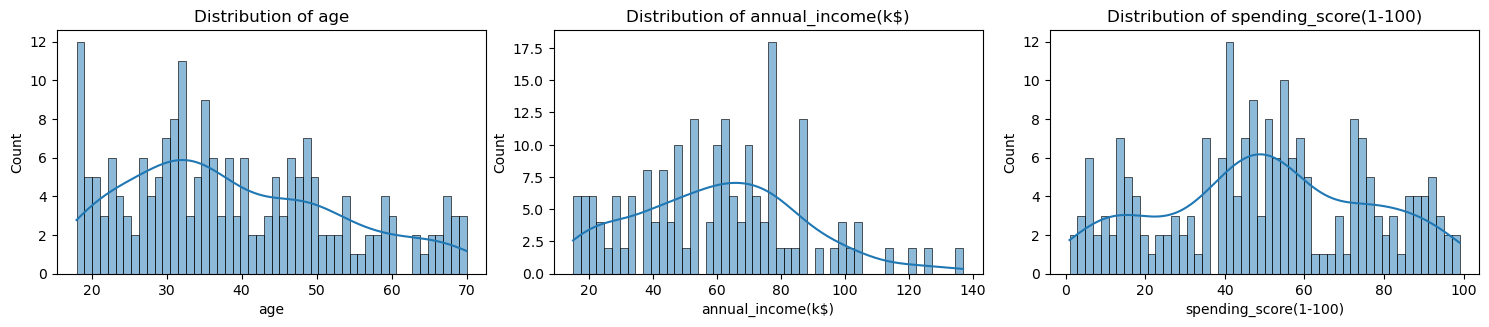

In [18]:
# 7.b Numerical columns distribution visualization
plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_columns, start=1):
    plt.subplot(4, 3, i)
    sns.histplot(data[col], kde=True, bins=50)
    plt.title(f"Distribution of {col}")
    
plt.tight_layout()
plt.show()

In [19]:
# 7.c Statistical analysis of the numerical data
data.describe()

,customer_id,age,annual_income(k$),spending_score(1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


The average age is ~39 years old, having the youngest customer with 18 years old and the eldest with 70 years old. The average annual income, in thousands of dollars, is ~60.6; however, the minimum annual income is 15 and the maximum is 137, making a significant difference. Last, the spending score can go from 1 to 100, the average spending score of the customers is around 26. The histograms shows, at a glance, that the three distributions follow a symmetric distribution (e.g. normal distribution). However, a deeper statistical analysis should be done to determine it with high confidence.

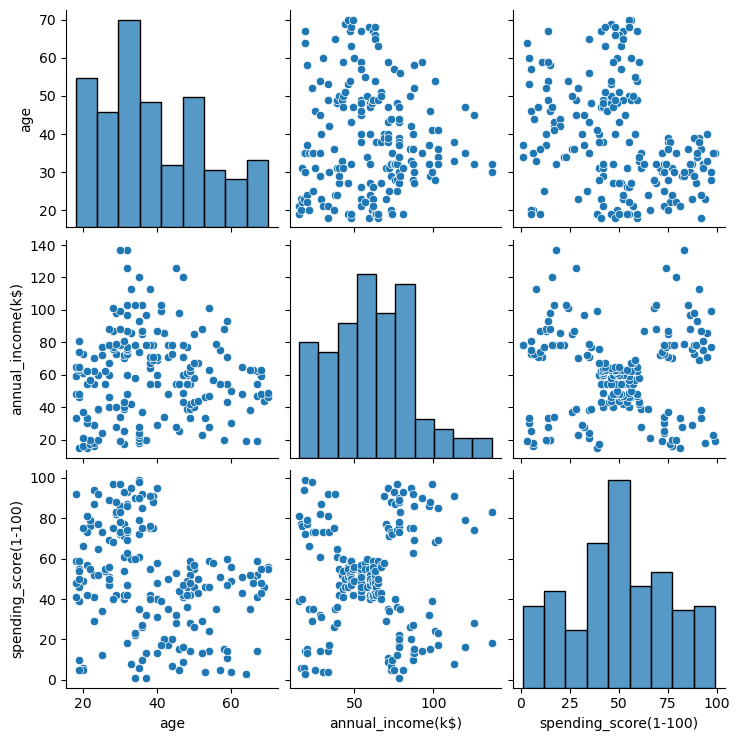

In [20]:
# 7.d Visualization of the data in a pairplot
data_model = data[['age', 'annual_income(k$)', 'spending_score(1-100)']]
sns.pairplot(data_model, diag_kind='hist')

Approximately, five groups or segments can be observed in the graph of annual income vs spending score.

# Scaling the features

In [21]:
# 8. Scale the features
# 8.a Make a copy of the data
data_scaled = data_model[['annual_income(k$)', 'spending_score(1-100)']].copy()

# 8.b Initialize the StandardScaler() and scale the data
scaler = StandardScaler()
data_scaled[['annual_income(k$)', 'spending_score(1-100)']] = scaler.fit_transform(
    data_model[['annual_income(k$)', 'spending_score(1-100)']])

# 8.c Visualize the scaled data
data_scaled.head()

,annual_income(k$),spending_score(1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


It's important to scale the data for models like KMeans as these models are based on distance calculations (Euclidean distance) and if by the contrary, the data is not scaled before, it can lead to bias results as the features with the largest numerical ranges will dominate.

# Elbow Method for Optimal Number of Clusters Calculation

c:\Users\paul_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\paul_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\paul_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\paul_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

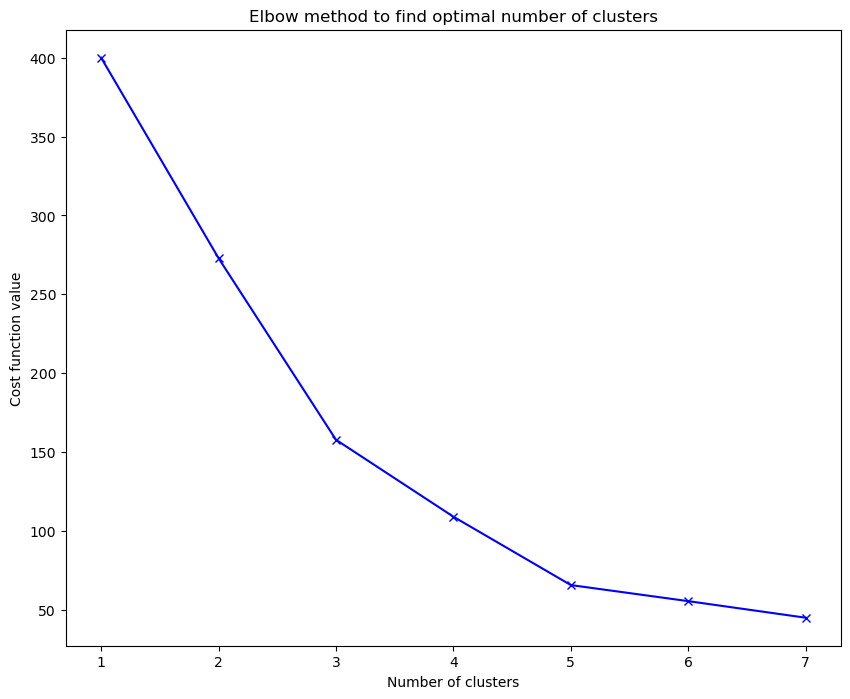

In [22]:
# 9.a Elbow method to find optimal number of clusters
distortion = []
K = range(1, 8)
for k in K:
    model = KMeans(n_clusters=k, random_state=12345)
    model.fit(data_scaled)
    distortion.append(model.inertia_)

# 9.b Visualize the results
plt.figure(figsize=(10, 8))
plt.plot(K, distortion, 'bx-')
plt.title('Elbow method to find optimal number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Cost function value')
plt.show()

In [23]:
# 9.c Silhouette score for clustering optimization
for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=12345)
    labels = model.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    print(f'Clusters: {k}, Silhouette score: {score:.2f}')

Clusters: 2, Silhouette score: 0.39
Clusters: 3, Silhouette score: 0.47
Clusters: 4, Silhouette score: 0.49
Clusters: 5, Silhouette score: 0.55
Clusters: 6, Silhouette score: 0.54
Clusters: 7, Silhouette score: 0.53


c:\Users\paul_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\paul_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\paul_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\paul_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Based on the silhouette score, five clusters is the optimal number of cluster for this dataset.

In [24]:
# 9.d Assign the optimal number of cluster to n_clusters variable
n_clusters = 5

# KMeans Clustering Model

In [25]:
# 10.a KMeans model with 5 clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=12345)
kmeans_labels = kmeans.fit_predict(data_scaled)

c:\Users\paul_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


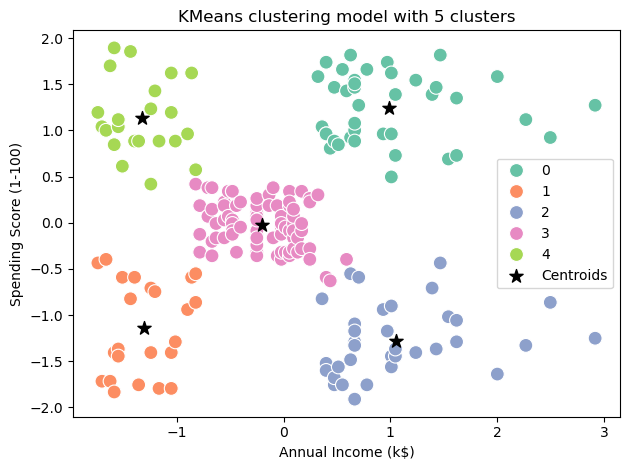

In [26]:
# 10.b Visualize the results of the segmentation model
sns.scatterplot(x=data_scaled['annual_income(k$)'], y=data_scaled['spending_score(1-100)'], hue=kmeans_labels, s=100, palette='Set2')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='black',marker='*',label='Centroids')

plt.title('KMeans clustering model with {} clusters'.format(5))
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# 11. Silhouette score for KMeans with 5 clusters
print(f'KMeans silhouette score: {silhouette_score(data_scaled, kmeans_labels):.4f}')

KMeans silhouette score: 0.5547


# AgglomerativeClustering Model

In [28]:
# 12.a AgglomerativeClustering model with 5 clusters
agg = AgglomerativeClustering(n_clusters=n_clusters)
agg_labels = agg.fit_predict(data_scaled)

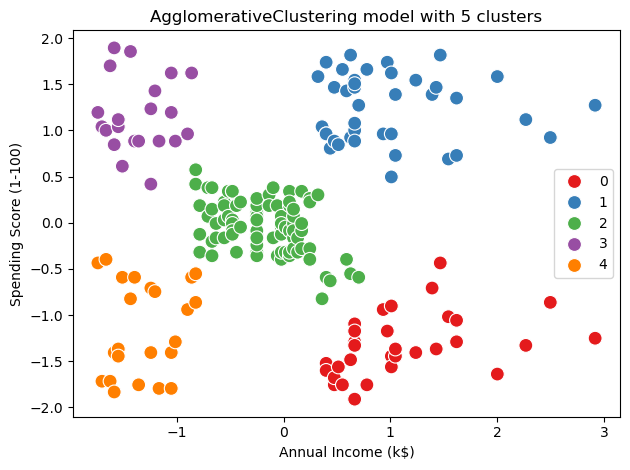

In [29]:
# 12.b Visualize the results of the AgglomerativeClustering model
sns.scatterplot(x=data_scaled['annual_income(k$)'], y=data_scaled['spending_score(1-100)'], hue=agg_labels, s=100, palette='Set1')

plt.title('AgglomerativeClustering model with {} clusters'.format(5))
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# 13. Silhouette score for AgglomerativeClustering with 5 clusters
print(f'AgglomerativeClustering silhouette score: {silhouette_score(data_scaled, agg_labels):.4f}')

AgglomerativeClustering silhouette score: 0.5538


Silhouette score evaluates the quality of a clustering algorithm. It goes from -1 to 1 and the nearest to +1 indicates an excellent clustering. Based on the silhouette score results, KMeans performs sligthly better, there's no a significant difference, on this dataset.

# Results And Conclusions

In [31]:
# 14. Results of KMeans clustering model
results = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_).round(), columns=data_scaled.columns)
results

,annual_income(k$),spending_score(1-100)
0,87.0,82.0
1,26.0,21.0
2,88.0,17.0
3,55.0,50.0
4,26.0,79.0


There are five clusters that can be interpreted as five customer segmentations.
* Cluster 1: Customers with high annual income and high spending score (primary target group for premium offers)
* Cluster 2: Customers with low annual income and low spending score (Less sensitive to marketing offers)
* Cluster 3: Customer with high annual income but low spending score (Can be sensitive to good discount offers and premium offers)
* Cluster 4: Customer with average annual income and moderate spending activity (Average loyalty)
* Cluster 5: Customers with low annual income but high spending score (Potential for personalized offers)

As a result of this project, I have practiced and become more familiar with the tecniques of unsupervised machine learning (clustering). In this project I analyzed, scaled and used two clustering techniques to compare the results and according to those, KMeans clustering techniques achieved better performance on this dataset. This model allowed to group mall customers in order to offer personalized offers.<p>I'll continue to practiceto enhance my skills on unsupervised machine learning techniques.